# Financial Market Analytics & Decision Intelligence

## Stock Market Data Analysis and Prediction

This notebook performs exploratory data analysis, financial feature engineering,
baseline comparison, machine-learning modelling, and prediction evaluation.

> **Important:** This project is for analytical and educational purposes.
> Market predictions are inherently uncertain and should not be treated as
> financial advice.


## 1. Objectives

The analysis focuses on:

- Understanding historical OHLCV market behaviour
- Performing data-quality validation
- Engineering financial time-series features
- Establishing a simple baseline
- Training a neural-network regression model
- Evaluating prediction performance
- Comparing actual and predicted prices
- Preparing the model for integration with the Flask dashboard


## 2. Import Libraries

In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 3. Load Dataset

In [2]:
DATA_PATH = "../data/stock_data.csv"

df = pd.read_csv(DATA_PATH)

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (522, 6)


,Date,Open,High,Low,Close,Volume
0,2023-01-02,100.00,100.93,99.36,100.00,51953
1,2023-01-03,98.63,101.45,98.63,101.04,72777
2,2023-01-04,100.20,101.54,99.93,100.81,69091
3,2023-01-05,100.61,102.39,100.61,102.17,100721
4,2023-01-06,101.88,106.53,101.88,105.33,90270


## 4. Dataset Overview

In [3]:
print("Rows:", len(df))
print("Columns:", list(df.columns))

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())


Rows: 522
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Data types:


Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object


Missing values:


Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

## 5. Descriptive Statistics

In [4]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Date,522,2023-12-31 21:39:18.620689408,2023-01-02 00:00:00,2023-07-03 06:00:00,2024-01-01 12:00:00,2024-07-01 18:00:00,2024-12-31 00:00:00,NaN
Open,522.0,107.636571,78.59,89.295,106.02,124.21,157.17,19.088172
High,522.0,109.200077,79.45,90.4,107.295,125.725,157.17,19.377969
Low,522.0,106.047203,78.56,87.1675,104.285,122.8125,153.34,18.708846
Close,522.0,107.634444,79.04,89.0725,105.97,124.2675,156.52,19.072888
Volume,522.0,66879.530651,25357.0,44435.75,68610.5,87838.25,118121.0,24196.263979


## 6. Closing Price History

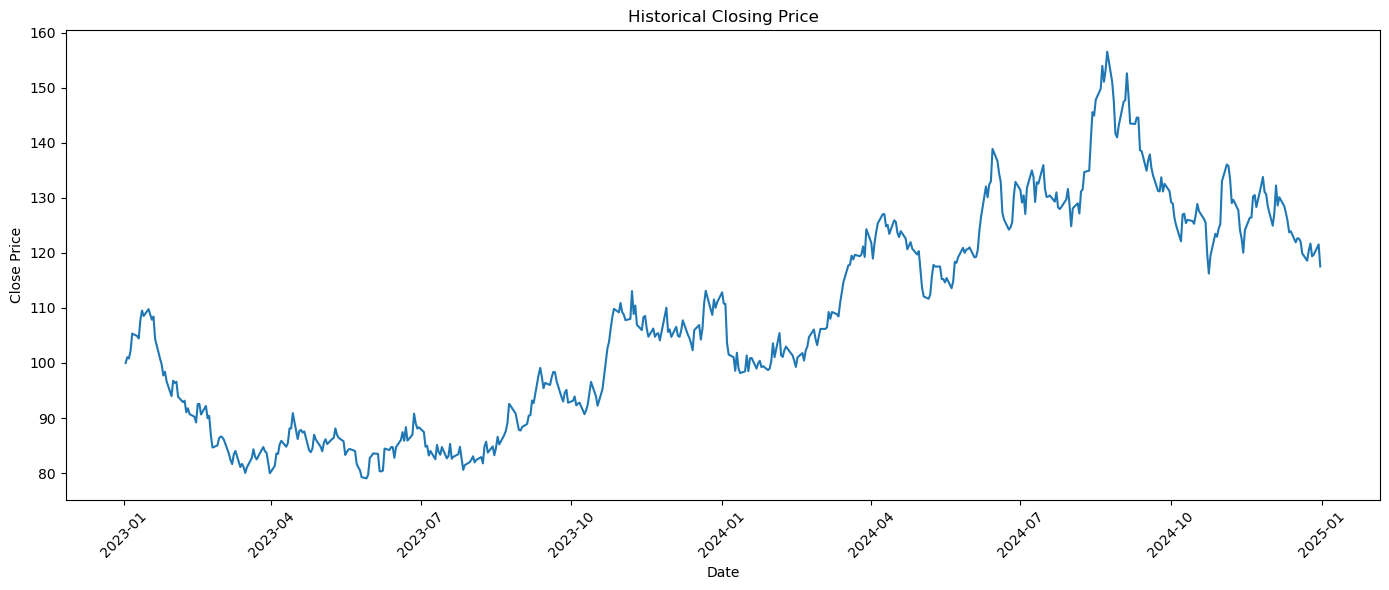

In [5]:
plt.figure(figsize=(14, 6))

plt.plot(df["Date"], df["Close"])

plt.title("Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Trading Volume

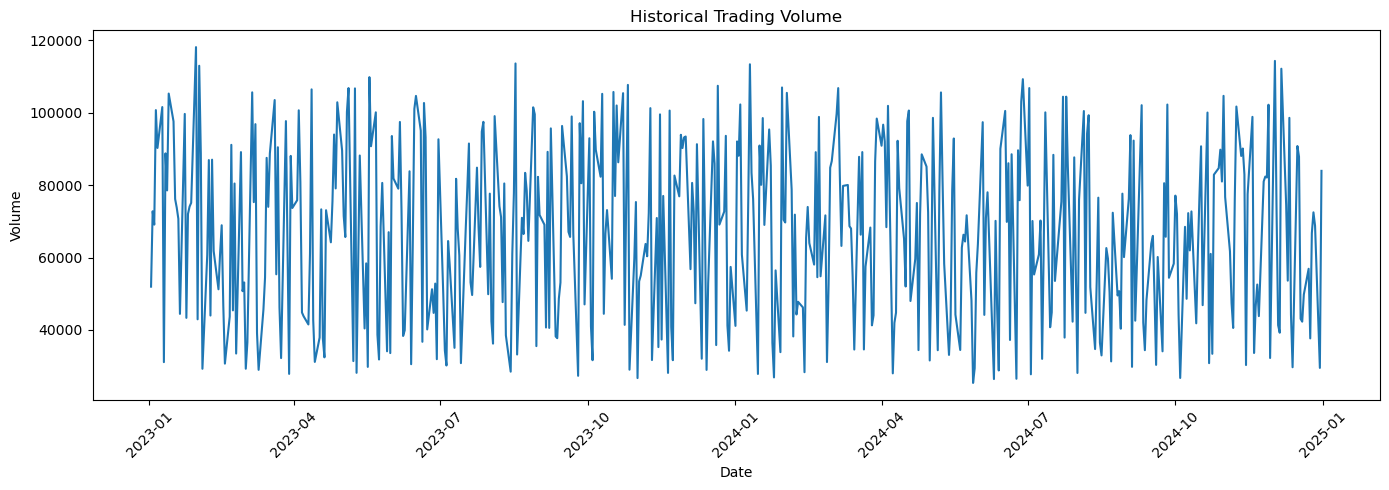

In [6]:
plt.figure(figsize=(14, 5))

plt.plot(df["Date"], df["Volume"])

plt.title("Historical Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Return Feature Engineering

In [7]:
df["Return_1D"] = df["Close"].pct_change()
df["Return_5D"] = df["Close"].pct_change(5)
df["Return_20D"] = df["Close"].pct_change(20)

df[[
    "Date",
    "Close",
    "Return_1D",
    "Return_5D",
    "Return_20D"
]].tail()


,Date,Close,Return_1D,Return_5D,Return_20D
517,2024-12-25,121.68,0.010463,-0.007261,-0.071570
518,2024-12-26,119.37,-0.018984,-0.021878,-0.086198
519,2024-12-27,119.66,0.002429,-0.001918,-0.068069
520,2024-12-30,121.52,0.015544,0.024880,-0.027217
521,2024-12-31,117.52,-0.032916,-0.024082,-0.076754


## 9. Moving Average Features

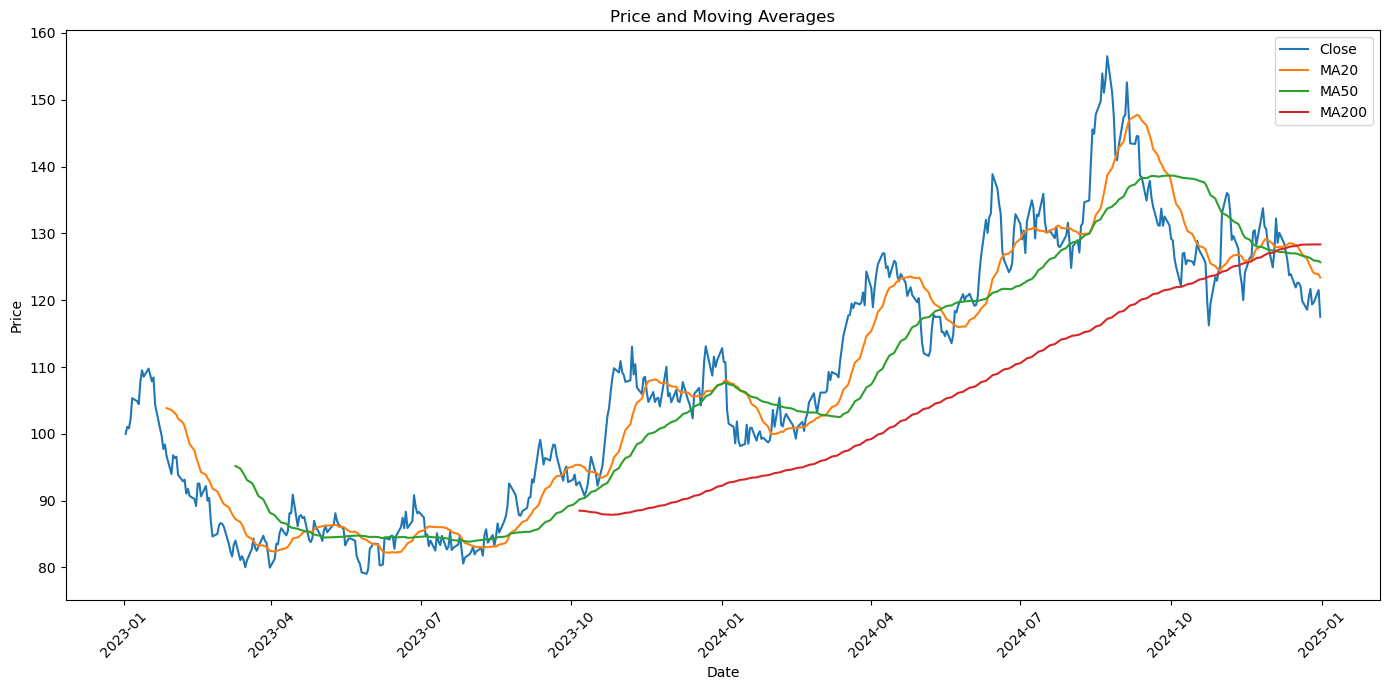

In [8]:
df["MA20"] = df["Close"].rolling(20).mean()
df["MA50"] = df["Close"].rolling(50).mean()
df["MA200"] = df["Close"].rolling(200).mean()

plt.figure(figsize=(14, 7))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["MA20"], label="MA20")
plt.plot(df["Date"], df["MA50"], label="MA50")
plt.plot(df["Date"], df["MA200"], label="MA200")

plt.title("Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 10. Volatility Analysis

In [9]:
df["Rolling_Volatility_20D"] = (
    df["Return_1D"]
    .rolling(20)
    .std()
)

df["Annualized_Volatility"] = (
    df["Rolling_Volatility_20D"]
    * np.sqrt(252)
)

df[[
    "Date",
    "Rolling_Volatility_20D",
    "Annualized_Volatility"
]].tail()


,Date,Rolling_Volatility_20D,Annualized_Volatility
517,2024-12-25,0.016679,0.264774
518,2024-12-26,0.017031,0.270351
519,2024-12-27,0.016821,0.267032
520,2024-12-30,0.016353,0.259597
521,2024-12-31,0.017076,0.271068


## 11. Drawdown Analysis

In [10]:
running_max = df["Close"].cummax()

df["Drawdown"] = (
    (df["Close"] - running_max)
    / running_max
)

maximum_drawdown = df["Drawdown"].min()

print(
    f"Maximum historical drawdown: "
    f"{maximum_drawdown * 100:.2f}%"
)


Maximum historical drawdown: -27.99%


## 12. Volume Activity

In [11]:
df["Average_Volume_20D"] = (
    df["Volume"]
    .rolling(20)
    .mean()
)

df["Volume_Ratio"] = (
    df["Volume"]
    / df["Average_Volume_20D"]
)

df[[
    "Date",
    "Volume",
    "Average_Volume_20D",
    "Volume_Ratio"
]].tail()


,Date,Volume,Average_Volume_20D,Volume_Ratio
517,2024-12-25,66745,64545.75,1.034073
518,2024-12-26,72481,63059.40,1.149408
519,2024-12-27,68766,64885.50,1.059805
520,2024-12-30,29509,60645.30,0.486583
521,2024-12-31,83939,61159.35,1.372464


## 13. Prediction Target

The target is the **next trading day's closing price**.

The target is shifted by one observation so that today's market information
is used to estimate tomorrow's close.


In [12]:
df["Target"] = df["Close"].shift(-1)

model_df = df.dropna().copy()

print("Model dataset shape:", model_df.shape)


Model dataset shape: (322, 18)


## 14. Model Features

In [13]:
FEATURES = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1D",
    "Return_5D",
    "Return_20D",
    "MA20",
    "MA50",
    "MA200",
    "Rolling_Volatility_20D",
    "Volume_Ratio",
]

model_df = model_df.dropna(
    subset=FEATURES + ["Target"]
).copy()

X = model_df[FEATURES]
y = model_df["Target"]

print("Features:", FEATURES)
print("X shape:", X.shape)
print("y shape:", y.shape)


Features: ['Open', 'High', 'Low', 'Close', 'Volume', 'Return_1D', 'Return_5D', 'Return_20D', 'MA20', 'MA50', 'MA200', 'Rolling_Volatility_20D', 'Volume_Ratio']
X shape: (322, 13)
y shape: (322,)


## 15. Chronological Train/Test Split

Financial time-series data must preserve temporal order.

A random train/test split can introduce future information into the training
process, so the data is split chronologically.


In [14]:
split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()

y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 257
Testing samples: 65


## 16. Feature Scaling

In [15]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training data scaled.")
print("Test data transformed using the training scaler.")


Training data scaled.
Test data transformed using the training scaler.


## 17. Naive Baseline

In [16]:
baseline_predictions = X_test["Close"].values

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print(f"Baseline MAE:  {baseline_mae:.4f}")
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Baseline R²:   {baseline_r2:.4f}")


Baseline MAE:  2.0582
Baseline RMSE: 2.5746
Baseline R²:   0.6588


## 18. Neural Network Regression Model

In [17]:
tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

## 19. Model Training

In [18]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)


Epoch 1/50


1/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 10655.6465 - mae: 102.9968

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 12751.5391 - mae: 112.3777 - val_loss: 18983.8398 - val_mae: 137.5210


Epoch 2/50


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 10593.2383 - mae: 102.6948

...

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 225.6475 - mae: 13.2332

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 171.4906 - mae: 10.6921 - val_loss: 366.1986 - val_mae: 16.2340


Epoch 50/50


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 222.6778 - mae: 13.1223

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 169.3307 - mae: 10.6255 - val_loss: 359.3752 - val_mae: 16.0686


## 20. Training History

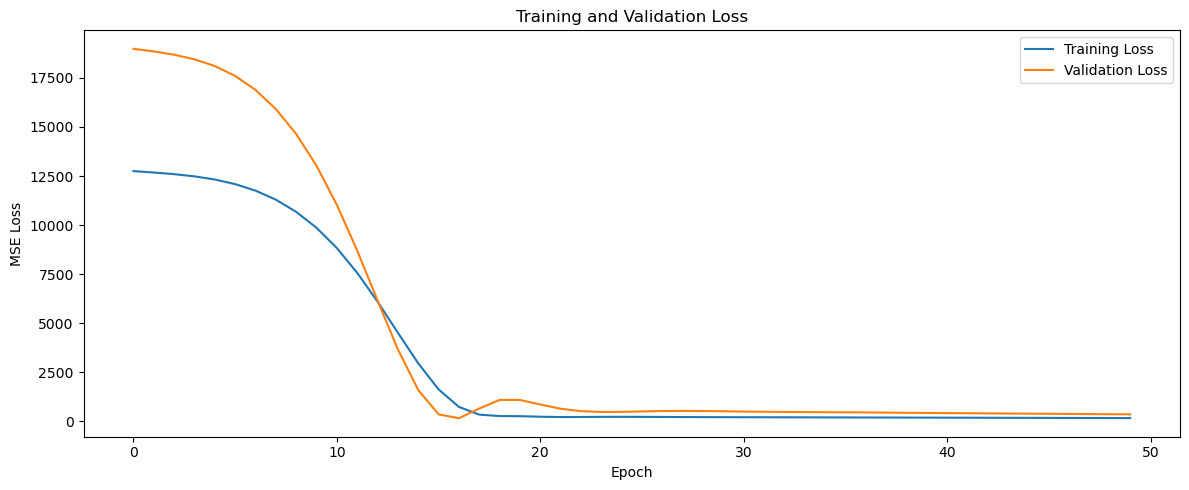

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()


## 21. Generate Predictions

In [20]:
predictions = model.predict(
    X_test_scaled,
    verbose=0
).flatten()

print("Predictions generated:", len(predictions))


Predictions generated: 65


## 22. Model Evaluation

In [21]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print(f"Neural Network MAE:  {mae:.4f}")
print(f"Neural Network RMSE: {rmse:.4f}")
print(f"Neural Network R²:   {r2:.4f}")


Neural Network MAE:  13.9800
Neural Network RMSE: 17.2669
Neural Network R²:   -14.3460


## 23. Baseline vs Neural Network

In [22]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Neural Network"
    ],
    "MAE": [
        baseline_mae,
        mae
    ],
    "RMSE": [
        baseline_rmse,
        rmse
    ],
    "R2": [
        baseline_r2,
        r2
    ]
})

comparison


,Model,MAE,RMSE,R2
0,Naive Baseline,2.058154,2.574610,0.658814
1,Neural Network,13.979954,17.266863,-14.346003


## 24. Actual vs Predicted Prices

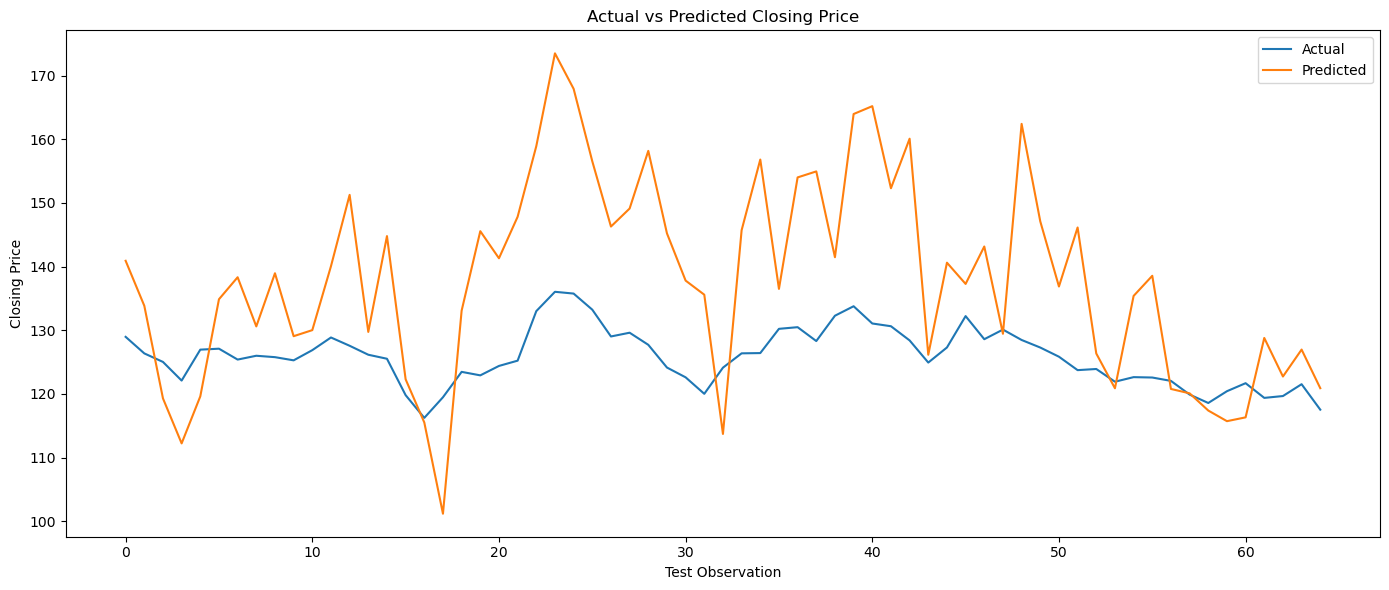

In [23]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    predictions,
    label="Predicted"
)

plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Test Observation")
plt.ylabel("Closing Price")
plt.legend()
plt.tight_layout()
plt.show()


## 25. Prediction Error Analysis

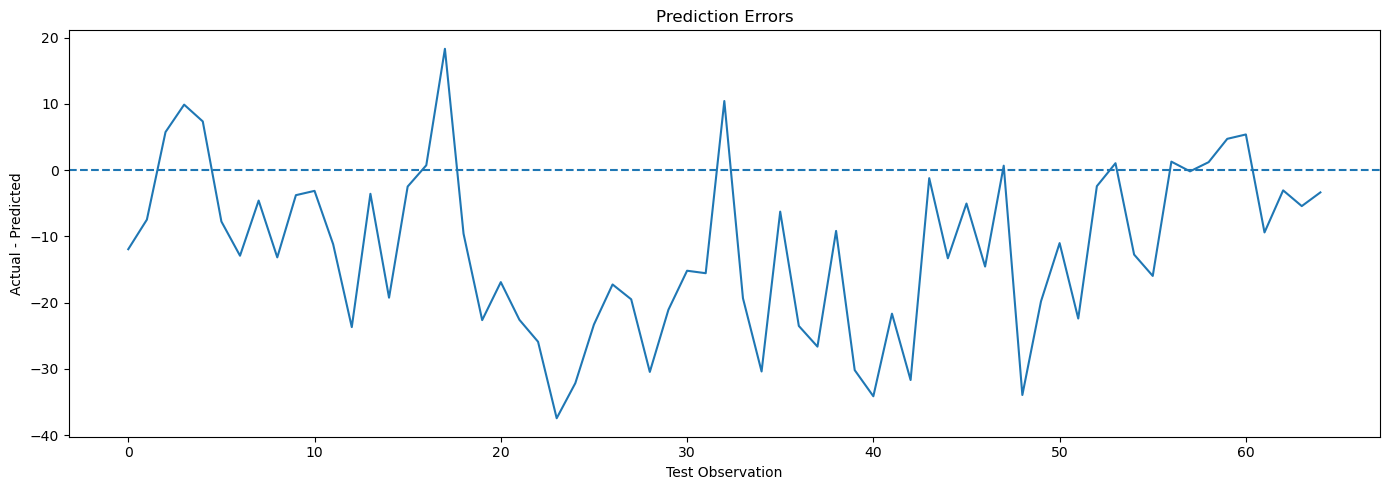

In [24]:
errors = y_test.values - predictions

plt.figure(figsize=(14, 5))

plt.plot(errors)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Prediction Errors")
plt.xlabel("Test Observation")
plt.ylabel("Actual - Predicted")
plt.tight_layout()
plt.show()


## 26. Error Statistics

In [25]:
error_summary = pd.Series(errors).describe()

error_summary


count    65.000000
mean    -11.931147
std      12.578813
min     -37.464501
25%     -21.679937
50%     -11.950812
75%      -3.067814
max      18.297072
dtype: float64

## 27. Latest Next-Day Prediction

In [26]:
latest_features = X.iloc[[-1]]

latest_scaled = scaler.transform(
    latest_features
)

next_day_prediction = float(
    model.predict(
        latest_scaled,
        verbose=0
    )[0][0]
)

current_price = float(
    df["Close"].iloc[-1]
)

predicted_change = (
    (next_day_prediction / current_price) - 1
) * 100

print(f"Current close: {current_price:.2f}")
print(
    f"Predicted next close: "
    f"{next_day_prediction:.2f}"
)
print(
    f"Predicted change: "
    f"{predicted_change:.2f}%"
)


Current close: 117.52
Predicted next close: 120.89
Predicted change: 2.87%



# 28. Model Diagnostics

The neural network is compared against the naive persistence
baseline to determine whether the learned model provides genuine
out-of-sample predictive value.

A model should only be integrated into the dashboard if it
demonstrates meaningful performance relative to the baseline.


In [27]:

diagnostic_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Naive Baseline": [
        baseline_mae,
        baseline_rmse,
        baseline_r2,
    ],
    "Neural Network": [
        mae,
        rmse,
        r2,
    ],
})

diagnostic_results


,Metric,Naive Baseline,Neural Network
0,MAE,2.058154,13.979954
1,RMSE,2.574610,17.266863
2,R2,0.658814,-14.346003



## 28.1 Prediction Statistics

The prediction distribution is inspected to identify systematic
bias, excessive compression, or unstable predictions.


In [28]:

prediction_summary = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions,
})

print("Actual price statistics:")
display(prediction_summary["Actual"].describe())

print("\nPredicted price statistics:")
display(prediction_summary["Predicted"].describe())

print("\nPrediction bias:")
print(
    f"Mean prediction error: "
    f"{errors.mean():.4f}"
)

print(
    f"Mean absolute error: "
    f"{np.abs(errors).mean():.4f}"
)


Actual price statistics:


count     65.000000
mean     125.825077
std        4.442040
min      116.230000
25%      122.600000
50%      125.840000
75%      128.590000
max      136.040000
Name: Actual, dtype: float64


Predicted price statistics:


count     65.000000
mean     137.756226
std       15.619937
min      101.172928
25%      126.346298
50%      137.798950
75%      147.103775
max      173.504501
Name: Predicted, dtype: float64


Prediction bias:
Mean prediction error: -11.9311
Mean absolute error: 13.9800



## 28.2 Prediction vs Actual Scatter

A well-calibrated regression model should produce predictions
that approximately follow the diagonal relationship between
actual and predicted values.


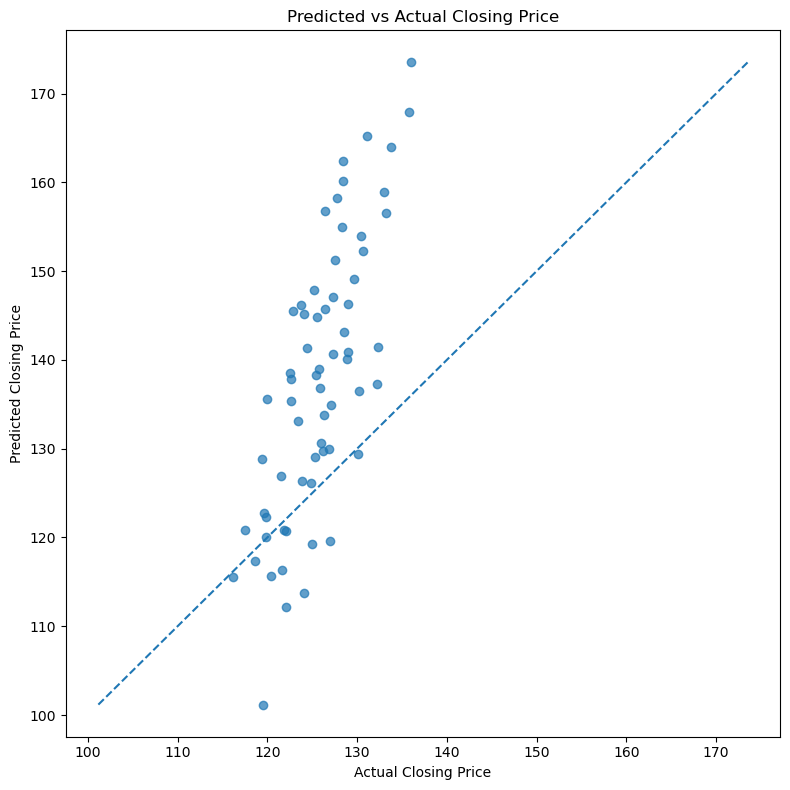

In [29]:

plt.figure(figsize=(8, 8))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

minimum = min(
    y_test.min(),
    predictions.min()
)

maximum = max(
    y_test.max(),
    predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Closing Price")
plt.ylabel("Predicted Closing Price")
plt.title("Predicted vs Actual Closing Price")

plt.tight_layout()
plt.show()



## 28.3 Baseline Advantage

The percentage improvement or deterioration of the neural network
relative to the naive baseline is calculated for each evaluation
metric.


In [30]:

mae_change = (
    (mae - baseline_mae)
    / baseline_mae
    * 100
)

rmse_change = (
    (rmse - baseline_rmse)
    / baseline_rmse
    * 100
)

print(
    f"MAE change vs baseline: "
    f"{mae_change:+.2f}%"
)

print(
    f"RMSE change vs baseline: "
    f"{rmse_change:+.2f}%"
)

if mae < baseline_mae and rmse < baseline_rmse:
    print(
        "The neural network outperforms the naive baseline."
    )
else:
    print(
        "The neural network does not outperform "
        "the naive baseline."
    )


MAE change vs baseline: +579.25%
RMSE change vs baseline: +570.66%
The neural network does not outperform the naive baseline.



## 28.4 Model Diagnostic Conclusion

The evaluation indicates whether the neural network should be
retained as the primary forecasting model or whether the modelling
formulation should be improved before production integration.


In [31]:

if mae < baseline_mae and rmse < baseline_rmse and r2 > baseline_r2:
    diagnostic_conclusion = (
        "The neural network demonstrates improved "
        "out-of-sample performance over the naive baseline."
    )
else:
    diagnostic_conclusion = (
        "The neural network currently underperforms the "
        "naive persistence baseline. The forecasting formulation "
        "should be improved before deployment."
    )

print(diagnostic_conclusion)


The neural network currently underperforms the naive persistence baseline. The forecasting formulation should be improved before deployment.


## 28. Model Limitations

This model should be interpreted as an analytical experiment rather than a
reliable trading system.

Important limitations include:

- Financial markets are highly non-stationary.
- Historical OHLCV data does not capture all market information.
- News, macroeconomic events, sentiment, and liquidity can affect prices.
- Regression accuracy does not imply profitable trading performance.
- The model predicts price levels rather than actual trading returns.
- Longer-horizon forecasts accumulate uncertainty.


## 29. Conclusion

The analysis establishes a complete machine-learning workflow:

**Data → Validation → Feature Engineering → Chronological Split → Scaling →
Baseline → Neural Network → Evaluation → Error Analysis**

The resulting model can serve as the machine-learning component of the Flask
Financial Market Analytics and Decision Intelligence Dashboard.



# 30. Alternative Forecasting Formulation — Next-Day Return

The previous experiment predicted the absolute next-day closing price.

This section reformulates the problem as **next-day return prediction**.

Instead of directly predicting:

`Tomorrow's Close`

the model predicts:

`Tomorrow's Return`

The predicted return can then be converted back into a price estimate:

`Predicted Price = Current Price × (1 + Predicted Return)`

This formulation is tested independently against the existing
persistence baseline.


In [32]:

# Create next-day return target

return_df = df.copy()

return_df["Target_Return"] = (
    return_df["Close"].shift(-1) / return_df["Close"]
) - 1

return_df = return_df.dropna().copy()

print("Return forecasting dataset:", return_df.shape)
return_df[["Date", "Close", "Target_Return"]].tail()


Return forecasting dataset: (322, 19)


,Date,Close,Target_Return
516,2024-12-24,120.42,0.010463
517,2024-12-25,121.68,-0.018984
518,2024-12-26,119.37,0.002429
519,2024-12-27,119.66,0.015544
520,2024-12-30,121.52,-0.032916



## 31. Return Model Features

The same engineered market features are retained so that the experiment
changes the forecasting target rather than introducing an unrelated
feature set.


In [33]:

RETURN_FEATURES = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1D",
    "Return_5D",
    "Return_20D",
    "MA20",
    "MA50",
    "MA200",
    "Rolling_Volatility_20D",
    "Volume_Ratio",
]

return_df = return_df.dropna(
    subset=RETURN_FEATURES + ["Target_Return"]
).copy()

X_return = return_df[RETURN_FEATURES]
y_return = return_df["Target_Return"]

split_return = int(len(return_df) * 0.8)

X_return_train = X_return.iloc[:split_return].copy()
X_return_test = X_return.iloc[split_return:].copy()

y_return_train = y_return.iloc[:split_return].copy()
y_return_test = y_return.iloc[split_return:].copy()

print("Training samples:", len(X_return_train))
print("Testing samples:", len(X_return_test))


Training samples: 257
Testing samples: 65



## 32. Scale Return Model Features

The scaler is fitted only on the chronological training set to prevent
future information from leaking into the training process.


In [34]:

return_scaler = MinMaxScaler()

X_return_train_scaled = return_scaler.fit_transform(
    X_return_train
)

X_return_test_scaled = return_scaler.transform(
    X_return_test
)

print("Return-model features scaled successfully.")


Return-model features scaled successfully.



## 33. Return Prediction Neural Network


In [35]:

tf.random.set_seed(42)
np.random.seed(42)

return_model = Sequential([
    Input(shape=(X_return_train_scaled.shape[1],)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

return_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

return_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)


## 34. Train Return Model


In [36]:

return_history = return_model.fit(
    X_return_train_scaled,
    y_return_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    shuffle=False,
    verbose=1
)


Epoch 1/50


1/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - loss: 0.2729 - mae: 0.4828

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0980 - mae: 0.2797 - val_loss: 0.0180 - val_mae: 0.1236


Epoch 2/50


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0241 - mae: 0.1264

...

1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.9244e-04 - mae: 0.0170

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2616e-04 - mae: 0.0143 - val_loss: 7.1538e-04 - val_mae: 0.0211


Epoch 50/50


1/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 4.9145e-04 - mae: 0.0169

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 3.2442e-04 - mae: 0.0143 - val_loss: 7.0897e-04 - val_mae: 0.0210



## 35. Generate Return Predictions


In [37]:

return_predictions = return_model.predict(
    X_return_test_scaled,
    verbose=0
).flatten()

print(
    "Return predictions generated:",
    len(return_predictions)
)


Return predictions generated: 65



## 36. Return Model Evaluation


In [38]:

return_mae = mean_absolute_error(
    y_return_test,
    return_predictions
)

return_rmse = np.sqrt(
    mean_squared_error(
        y_return_test,
        return_predictions
    )
)

return_r2 = r2_score(
    y_return_test,
    return_predictions
)

print(f"Return Model MAE:  {return_mae:.6f}")
print(f"Return Model RMSE: {return_rmse:.6f}")
print(f"Return Model R²:   {return_r2:.6f}")


Return Model MAE:  0.024844
Return Model RMSE: 0.030565
Return Model R²:   -1.226010



## 37. Directional Accuracy

For financial forecasting, correctly predicting the direction of movement
can be more informative than absolute price error.

A prediction is considered directionally correct when the predicted return
and actual return have the same sign.


In [39]:

actual_direction = np.sign(
    y_return_test.values
)

predicted_direction = np.sign(
    return_predictions
)

directional_accuracy = np.mean(
    actual_direction == predicted_direction
)

print(
    f"Directional Accuracy: "
    f"{directional_accuracy * 100:.2f}%"
)


Directional Accuracy: 47.69%



## 38. Return Prediction vs Persistence Baseline

For the return formulation, a natural persistence baseline predicts a
zero return for the next trading day.


In [40]:

zero_return_predictions = np.zeros(
    len(y_return_test)
)

zero_return_mae = mean_absolute_error(
    y_return_test,
    zero_return_predictions
)

zero_return_rmse = np.sqrt(
    mean_squared_error(
        y_return_test,
        zero_return_predictions
    )
)

zero_return_r2 = r2_score(
    y_return_test,
    zero_return_predictions
)

print(f"Zero-return baseline MAE:  {zero_return_mae:.6f}")
print(f"Zero-return baseline RMSE: {zero_return_rmse:.6f}")
print(f"Zero-return baseline R²:   {zero_return_r2:.6f}")


Zero-return baseline MAE:  0.016376
Zero-return baseline RMSE: 0.020524
Zero-return baseline R²:   -0.003698



## 39. Return Model Comparison


In [41]:

return_comparison = pd.DataFrame({
    "Model": [
        "Zero-Return Baseline",
        "Neural Network"
    ],
    "MAE": [
        zero_return_mae,
        return_mae
    ],
    "RMSE": [
        zero_return_rmse,
        return_rmse
    ],
    "R2": [
        zero_return_r2,
        return_r2
    ],
    "Directional_Accuracy": [
        50.0,
        directional_accuracy * 100
    ]
})

return_comparison


,Model,MAE,RMSE,R2,Directional_Accuracy
0,Zero-Return Baseline,0.016376,0.020524,-0.003698,50.000000
1,Neural Network,0.024844,0.030565,-1.226010,47.692308



## 40. Actual vs Predicted Returns


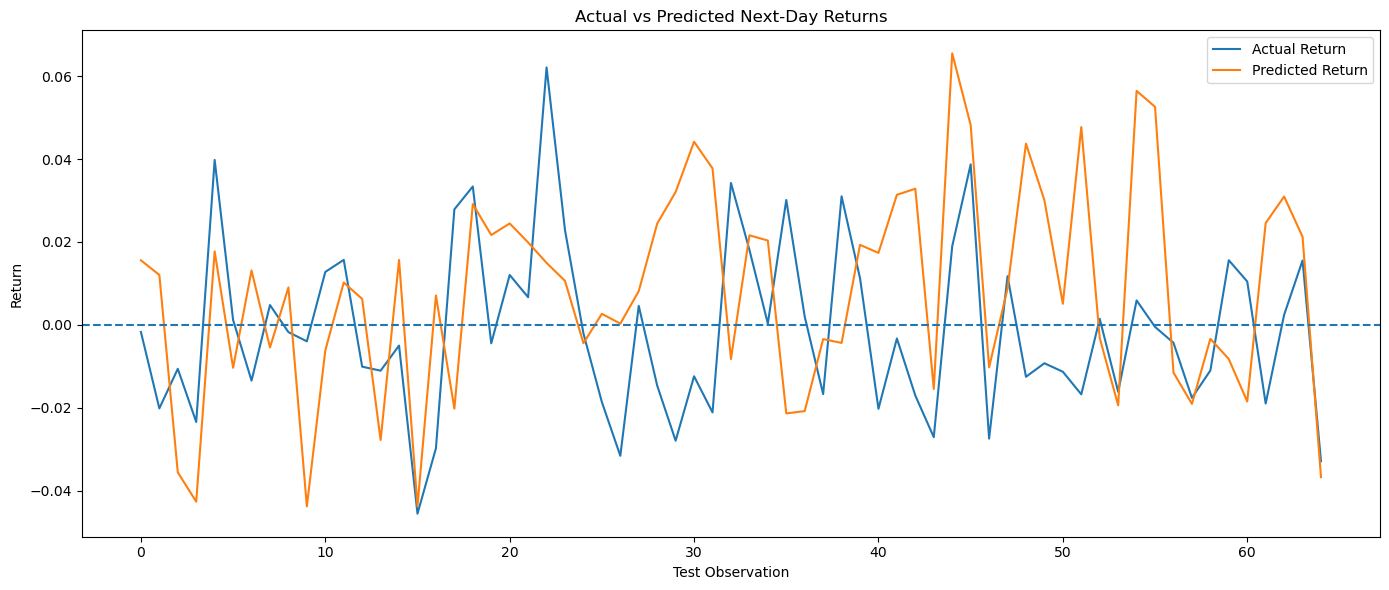

In [42]:

plt.figure(figsize=(14, 6))

plt.plot(
    y_return_test.values,
    label="Actual Return"
)

plt.plot(
    return_predictions,
    label="Predicted Return"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Actual vs Predicted Next-Day Returns")
plt.xlabel("Test Observation")
plt.ylabel("Return")
plt.legend()
plt.tight_layout()
plt.show()



## 41. Return Model Assessment

The return-based neural network should only be considered for dashboard
integration if it demonstrates meaningful improvement over the baseline.

The decision should be based on:

- MAE
- RMSE
- R²
- Directional Accuracy
- Stability of the predictions

A neural network should not be selected merely because it is more complex.


In [43]:

print("Return Forecasting Assessment")
print("=" * 50)

print(f"Zero-return baseline MAE: {zero_return_mae:.6f}")
print(f"Return model MAE:         {return_mae:.6f}")
print()

print(f"Zero-return baseline RMSE: {zero_return_rmse:.6f}")
print(f"Return model RMSE:         {return_rmse:.6f}")
print()

print(f"Return model R²:           {return_r2:.6f}")
print(
    f"Directional accuracy:     "
    f"{directional_accuracy * 100:.2f}%"
)

if return_mae < zero_return_mae and directional_accuracy > 0.50:
    print(
        "\nRESULT: Return model shows improvement over "
        "the zero-return baseline."
    )
else:
    print(
        "\nRESULT: Return model does not currently "
        "provide sufficient evidence of improvement."
    )


Return Forecasting Assessment
Zero-return baseline MAE: 0.016376
Return model MAE:         0.024844

Zero-return baseline RMSE: 0.020524
Return model RMSE:         0.030565

Return model R²:           -1.226010
Directional accuracy:     47.69%

RESULT: Return model does not currently provide sufficient evidence of improvement.



# 42. Gradient Boosting Benchmark

The previous feed-forward neural-network experiments did not outperform
simple persistence baselines.

This section evaluates a tree-based gradient boosting model on the same
engineered financial features.

The objective is to determine whether a nonlinear tabular model can extract
predictive information that the neural network failed to capture.


In [44]:

from sklearn.ensemble import HistGradientBoostingRegressor

print("Gradient Boosting benchmark initialized.")


Gradient Boosting benchmark initialized.



## 43. Chronological Gradient Boosting Dataset

The original next-day closing-price formulation is retained for direct
comparison with the earlier baseline and neural network experiments.


In [45]:

gb_df = df.copy()

gb_df["Target"] = gb_df["Close"].shift(-1)

gb_df = gb_df.dropna(
    subset=FEATURES + ["Target"]
).copy()

X_gb = gb_df[FEATURES]
y_gb = gb_df["Target"]

gb_split = int(len(gb_df) * 0.8)

X_gb_train = X_gb.iloc[:gb_split].copy()
X_gb_test = X_gb.iloc[gb_split:].copy()

y_gb_train = y_gb.iloc[:gb_split].copy()
y_gb_test = y_gb.iloc[gb_split:].copy()

print("Gradient Boosting training samples:", len(X_gb_train))
print("Gradient Boosting testing samples:", len(X_gb_test))


Gradient Boosting training samples: 257
Gradient Boosting testing samples: 65



## 44. Train Gradient Boosting Regressor

Gradient boosting is evaluated as a nonlinear tabular-data model.

Unlike the neural network, tree-based gradient boosting does not require
feature scaling.


In [46]:

gb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=42
)

gb_model.fit(
    X_gb_train,
    y_gb_train
)

print("Gradient Boosting model trained successfully.")


Gradient Boosting model trained successfully.



## 45. Generate Gradient Boosting Predictions


In [47]:

gb_predictions = gb_model.predict(
    X_gb_test
)

print(
    "Predictions generated:",
    len(gb_predictions)
)


Predictions generated: 65



## 46. Gradient Boosting Evaluation


In [48]:

gb_mae = mean_absolute_error(
    y_gb_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_gb_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_gb_test,
    gb_predictions
)

print(f"Gradient Boosting MAE:  {gb_mae:.4f}")
print(f"Gradient Boosting RMSE: {gb_rmse:.4f}")
print(f"Gradient Boosting R²:   {gb_r2:.4f}")


Gradient Boosting MAE:  3.3990
Gradient Boosting RMSE: 4.0362
Gradient Boosting R²:   0.1615



## 47. Gradient Boosting Directional Accuracy

Directional accuracy measures whether the model correctly identifies the
direction of the next-day price movement.


In [49]:

actual_price_change = (
    y_gb_test.values
    - X_gb_test["Close"].values
)

predicted_price_change = (
    gb_predictions
    - X_gb_test["Close"].values
)

gb_directional_accuracy = np.mean(
    np.sign(actual_price_change)
    == np.sign(predicted_price_change)
)

print(
    f"Gradient Boosting Directional Accuracy: "
    f"{gb_directional_accuracy * 100:.2f}%"
)


Gradient Boosting Directional Accuracy: 53.85%



## 48. Baseline vs Neural Network vs Gradient Boosting


In [50]:

model_comparison_extended = pd.DataFrame({
    "Model": [
        "Naive Persistence",
        "Dense Neural Network",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        mae,
        gb_mae
    ],
    "RMSE": [
        baseline_rmse,
        rmse,
        gb_rmse
    ],
    "R2": [
        baseline_r2,
        r2,
        gb_r2
    ],
    "Directional_Accuracy": [
        np.mean(
            np.sign(
                y_test.values
                - X_test["Close"].values
            )
            == np.sign(
                X_test["Close"].values
                - X_test["Close"].values
            )
        ) * 100,
        np.nan,
        gb_directional_accuracy * 100
    ]
})

model_comparison_extended


,Model,MAE,RMSE,R2,Directional_Accuracy
0,Naive Persistence,2.058154,2.574610,0.658814,0.000000
1,Dense Neural Network,13.979954,17.266863,-14.346003,NaN
2,Gradient Boosting,3.398993,4.036172,0.161491,53.846154



## 49. Actual vs Gradient Boosting Predictions


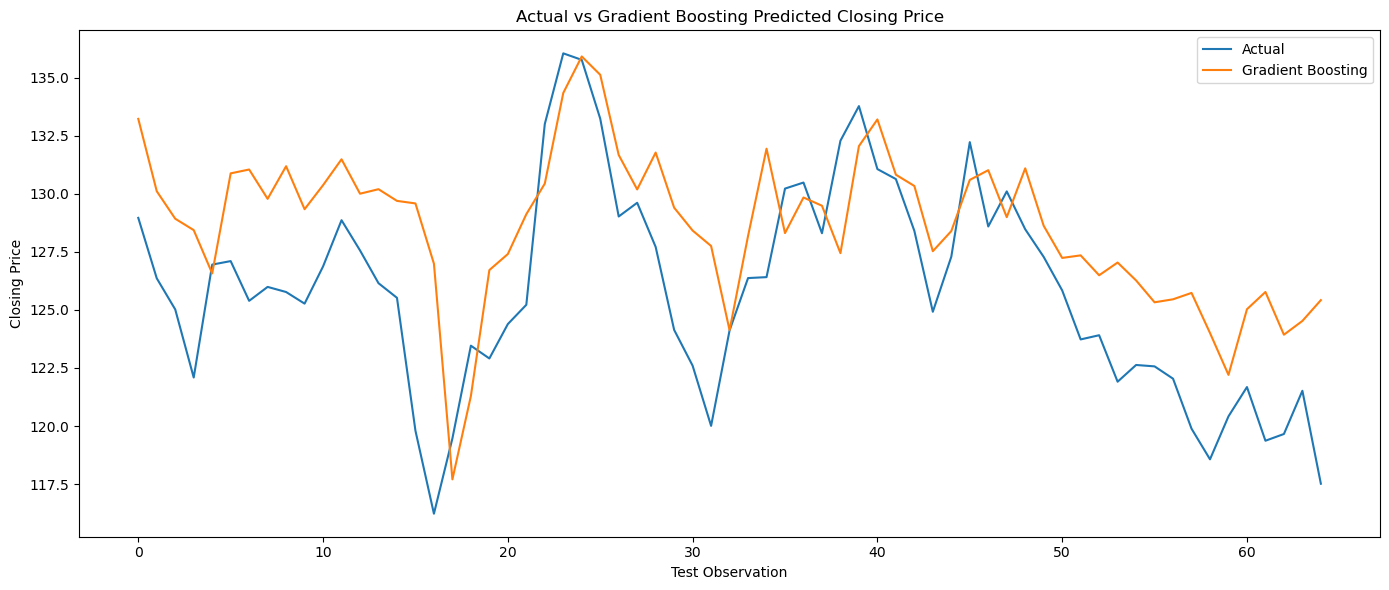

In [51]:

plt.figure(figsize=(14, 6))

plt.plot(
    y_gb_test.values,
    label="Actual"
)

plt.plot(
    gb_predictions,
    label="Gradient Boosting"
)

plt.title(
    "Actual vs Gradient Boosting Predicted Closing Price"
)

plt.xlabel("Test Observation")
plt.ylabel("Closing Price")

plt.legend()
plt.tight_layout()
plt.show()



## 50. Gradient Boosting Model Decision

The model is considered a candidate for deployment only if it provides
meaningful improvement over the persistence baseline.

The primary selection criteria are:

- Lower MAE
- Lower RMSE
- Higher R²
- Useful directional accuracy


In [52]:

print("Gradient Boosting Assessment")
print("=" * 50)

print(f"Baseline MAE:          {baseline_mae:.4f}")
print(f"Gradient Boosting MAE: {gb_mae:.4f}")
print()

print(f"Baseline RMSE:          {baseline_rmse:.4f}")
print(f"Gradient Boosting RMSE: {gb_rmse:.4f}")
print()

print(f"Baseline R²:          {baseline_r2:.4f}")
print(f"Gradient Boosting R²: {gb_r2:.4f}")
print()

print(
    f"Gradient Boosting Directional Accuracy: "
    f"{gb_directional_accuracy * 100:.2f}%"
)

if gb_mae < baseline_mae and gb_rmse < baseline_rmse:
    print(
        "\nRESULT: Gradient Boosting improves over "
        "the persistence baseline."
    )
else:
    print(
        "\nRESULT: Gradient Boosting does not currently "
        "outperform the persistence baseline."
    )


Gradient Boosting Assessment
Baseline MAE:          2.0582
Gradient Boosting MAE: 3.3990

Baseline RMSE:          2.5746
Gradient Boosting RMSE: 4.0362

Baseline R²:          0.6588
Gradient Boosting R²: 0.1615

Gradient Boosting Directional Accuracy: 53.85%

RESULT: Gradient Boosting does not currently outperform the persistence baseline.


In [53]:
# Correlation analysis for numerical market variables

correlation_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Return_1D",
    "Return_5D",
    "Return_20D",
    "MA20",
    "MA50",
    "MA200",
    "Rolling_Volatility_20D",
    "Volume_Ratio",
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

display(
    correlation_matrix.round(2)
)


,Open,High,Low,Close,Volume,Return_1D,Return_5D,Return_20D,MA20,MA50,MA200,Rolling_Volatility_20D,Volume_Ratio
Open,1.00,1.00,1.00,0.99,-0.05,-0.05,0.09,0.24,0.97,0.93,0.77,0.17,-0.02
High,1.00,1.00,1.00,1.00,-0.04,0.02,0.12,0.26,0.97,0.93,0.77,0.18,-0.02
Low,1.00,1.00,1.00,1.00,-0.04,0.02,0.12,0.26,0.97,0.93,0.77,0.16,-0.02
Close,0.99,1.00,1.00,1.00,-0.04,0.06,0.14,0.27,0.96,0.93,0.77,0.17,-0.02
Volume,-0.05,-0.04,-0.04,-0.04,1.00,0.08,-0.02,-0.01,-0.03,-0.05,-0.08,0.03,0.98
Return_1D,-0.05,0.02,0.02,0.06,0.08,1.00,0.42,0.22,-0.04,-0.05,-0.07,-0.06,0.06
Return_5D,0.09,0.12,0.12,0.14,-0.02,0.42,1.00,0.52,-0.07,-0.09,-0.14,-0.09,-0.06
Return_20D,0.24,0.26,0.26,0.27,-0.01,0.22,0.52,1.00,0.05,-0.11,-0.22,0.09,-0.02
MA20,0.97,0.97,0.97,0.96,-0.03,-0.04,-0.07,0.05,1.00,0.97,0.86,0.18,-0.01
MA50,0.93,0.93,0.93,0.93,-0.05,-0.05,-0.09,-0.11,0.97,1.00,0.93,0.15,-0.01


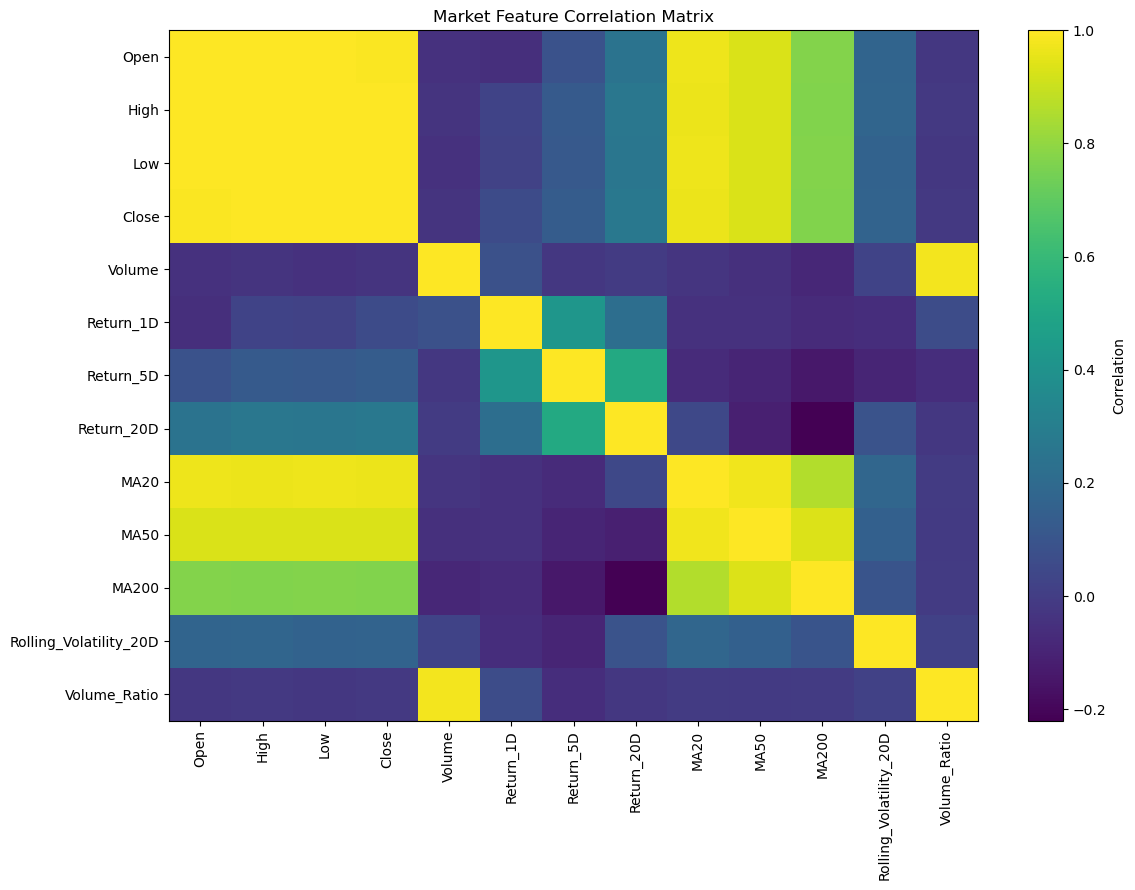

In [54]:
# Visualize feature correlations

plt.figure(figsize=(12, 9))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title(
    "Market Feature Correlation Matrix"
)

plt.tight_layout()
plt.show()
